## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import numpy as np
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle
import gc

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x0000028167F5B6D0> [0]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thrace'

In [4]:
years = range(2009, 2025)

In [6]:
timelines = []

for year in years:
    df = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_{year}_filled_mean_rain_shp.csv', encoding=enc)
    print(f'Year: {year} | {df.shape}')
    timelines.append(df)

Year: 2009 | (1192090, 44)
Year: 2010 | (1192090, 44)
Year: 2011 | (1192090, 44)
Year: 2012 | (1195356, 44)
Year: 2013 | (1192090, 44)
Year: 2014 | (1192090, 44)
Year: 2015 | (1192090, 44)
Year: 2016 | (1195356, 44)
Year: 2017 | (1192090, 44)
Year: 2018 | (1192090, 44)
Year: 2019 | (1192090, 44)
Year: 2020 | (1195356, 44)


C:\Users\dimit\AppData\Local\Temp\ipykernel_176960\1603407226.py:4: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_{year}_filled_mean_rain_shp.csv', encoding=enc)


Year: 2021 | (1192090, 44)
Year: 2022 | (1192090, 44)
Year: 2023 | (1192090, 44)
Year: 2024 | (1195356, 44)


In [7]:
# timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_2016-2018_filled.csv', encoding=enc)
# wnv_file = pd.read_csv(f'../../data/{NUTS0}_WNV_cases_GRID_2010-2021.csv', encoding=enc)

timeline_file = pd.concat(timelines, ignore_index=True, axis = 0)

In [8]:
del df
del timelines

gc.collect()

1417

In [9]:
timeline_file.tail()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
19086499,26.607560,41.407290,3265,2024-12-27,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,2024,12,0.226252,-0.074798,-0.303619,0.074798,0.250099,-0.057651,-0.294510,0.057651,0.040180,0.032756,0.025171,0.032756,14079.000000,13677.000000,0.000000,27,13990.322581,13638.225806,14369.068966,13934.965517,14415.483871,13885.967742,14911.166667,14116.400000,17.517450,18.530392,75.649018,253.240976,4.000000,2,1
19086500,26.607560,41.407290,3265,2024-12-28,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,2024,12,0.226252,-0.074798,-0.303619,0.074798,0.250099,-0.057651,-0.294510,0.057651,0.040180,0.032756,0.025171,0.032756,13770.000000,13677.000000,0.000000,28,13990.322581,13638.225806,14369.068966,13934.965517,14415.483871,13885.967742,14911.166667,14116.400000,16.110588,18.530392,75.649018,253.240976,4.000000,2,1
19086501,26.607560,41.407290,3265,2024-12-29,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,2024,12,0.226252,-0.074798,-0.303619,0.074798,0.250099,-0.057651,-0.294510,0.057651,0.040180,0.032756,0.025171,0.032756,13770.000000,13606.000000,0.000000,29,13990.322581,13638.225806,14369.068966,13934.965517,14415.483871,13885.967742,14911.166667,14116.400000,16.110588,17.517450,75.649018,253.240976,4.000000,2,1
19086502,26.607560,41.407290,3265,2024-12-30,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,2024,12,0.226252,-0.074798,-0.303619,0.074798,0.250099,-0.057651,-0.294510,0.057651,0.040180,0.032756,0.025171,0.032756,13882.000000,13568.000000,0.000000,30,13990.322581,13638.225806,14369.068966,13934.965517,14415.483871,13885.967742,14911.166667,14116.400000,16.110588,17.517450,75.649018,253.240976,4.000000,2,1
19086503,26.607560,41.407290,3265,2024-12-31,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,2024,12,0.226252,-0.074798,-0.303619,0.074798,0.250099,-0.057651,-0.294510,0.057651,0.040180,0.032756,0.025171,0.032756,13728.000000,13619.000000,0.000000,31,13990.322581,13638.225806,14369.068966,13934.965517,14415.483871,13885.967742,14911.166667,14116.400000,1.004902,17.517450,75.649018,253.240976,4.000000,2,1


In [10]:
timeline_file.shape

(19086504, 44)

In [11]:
# wnv_file.head()

In [12]:
timeline_file['lst_day'] = timeline_file['lst_day'].replace(r'\b\d{4}-\d{2}-\d{2}\b', np.nan, regex=True)
timeline_file['lst_night'] = timeline_file['lst_night'].replace(r'\b\d{4}-\d{2}-\d{2}\b', np.nan, regex=True)

In [13]:
timeline_file['lst_day'] = timeline_file['lst_day'].astype(float)
timeline_file['lst_night'] = timeline_file['lst_night'].astype(float)

In [14]:
timeline_file['lst_night']

0                   NaN
1                   NaN
2                   NaN
3                   NaN
4                   NaN
               ...     
19086499   13677.000000
19086500   13677.000000
19086501   13606.000000
19086502   13568.000000
19086503   13619.000000
Name: lst_night, Length: 19086504, dtype: float64

In [15]:
# wnv_file.shape

In [16]:
try:
    timeline_file.drop(columns=['Unnamed: 0'], inplace=True)
except KeyError:
    print ("column not found")

column not found


In [17]:
temprature_cols = timeline_file.filter(regex='^lst_*').columns.tolist()

timeline_file[temprature_cols] = timeline_file[temprature_cols].apply(lambda x : x * 0.02 - 273.15)

In [18]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,23.658820,41.335420,0,2009-01-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.130000,NaN,0.571116,1,2.065484,-2.724545,1.051429,-3.054286,4.324839,-4.054516,17.039333,3.170667,0.571116,0.571116,0.571116,0.571116,2.000000,2,2
1,23.658820,41.335420,0,2009-01-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.130000,NaN,2.849277,2,2.065484,-2.724545,1.051429,-3.054286,4.324839,-4.054516,17.039333,3.170667,3.420394,3.420394,3.420394,3.420394,2.000000,2,2
2,23.658820,41.335420,0,2009-01-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.130000,NaN,2.961702,3,2.065484,-2.724545,1.051429,-3.054286,4.324839,-4.054516,17.039333,3.170667,6.382096,6.382096,6.382096,6.382096,2.000000,2,2
3,23.658820,41.335420,0,2009-01-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.130000,NaN,3.528619,4,2.065484,-2.724545,1.051429,-3.054286,4.324839,-4.054516,17.039333,3.170667,9.910714,9.910714,9.910714,9.910714,2.000000,2,2
4,23.658820,41.335420,0,2009-01-05,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.130000,NaN,0.000000,5,2.065484,-2.724545,1.051429,-3.054286,4.324839,-4.054516,17.039333,3.170667,9.910714,9.910714,9.910714,9.910714,2.000000,2,2


In [19]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [20]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)

timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [21]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [22]:
timeline_file

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,month_sin,month_cos
0,23.658820,41.335420,0,2009-01-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.130000,NaN,0.571116,1,2.065484,-2.724545,1.051429,-3.054286,4.324839,-4.054516,17.039333,3.170667,0.571116,0.571116,0.571116,0.571116,2.000000,2,2,NaN,-0.329531,-1.001429,0.135161,10.105000,0.500000,0.866025
1,23.658820,41.335420,0,2009-01-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.130000,NaN,2.849277,2,2.065484,-2.724545,1.051429,-3.054286,4.324839,-4.054516,17.039333,3.170667,3.420394,3.420394,3.420394,3.420394,2.000000,2,2,NaN,-0.329531,-1.001429,0.135161,10.105000,0.500000,0.866025
2,23.658820,41.335420,0,2009-01-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.130000,NaN,2.961702,3,2.065484,-2.724545,1.051429,-3.054286,4.324839,-4.054516,17.039333,3.170667,6.382096,6.382096,6.382096,6.382096,2.000000,2,2,NaN,-0.329531,-1.001429,0.135161,10.105000,0.500000,0.866025
3,23.658820,41.335420,0,2009-01-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.130000,NaN,3.528619,4,2.065484,-2.724545,1.051429,-3.054286,4.324839,-4.054516,17.039333,3.170667,9.910714,9.910714,9.910714,9.910714,2.000000,2,2,NaN,-0.329531,-1.001429,0.135161,10.105000,0.500000,0.866025
4,23.658820,41.335420,0,2009-01-05,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.130000,NaN,0.000000,5,2.065484,-2.724545,1.051429,-3.054286,4.324839,-4.054516,17.039333,3.170667,9.910714,9.910714,9.910714,9.910714,2.000000,2,2,NaN,-0.329531,-1.001429,0.135161,10.105000,0.500000,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19086499,26.607560,41.407290,3265,2024-12-27,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,2024,12,0.226252,-0.074798,-0.303619,0.074798,0.250099,-0.057651,-0.294510,0.057651,0.040180,0.032756,0.025171,0.032756,8.430000,0.390000,0.000000,27,6.656452,-0.385484,14.231379,5.549310,15.159677,4.569355,25.073333,9.178000,17.517450,18.530392,75.649018,253.240976,4.000000,2,1,4.410000,3.135484,9.890345,9.864516,17.125667,-0.000000,1.000000
19086500,26.607560,41.407290,3265,2024-12-28,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,2024,12,0.226252,-0.074798,-0.303619,0.074798,0.250099,-0.057651,-0.294510,0.057651,0.040180,0.032756,0.025171,0.032756,2.250000,0.390000,0.000000,28,6.656452,-0.385484,14.231379,5.549310,15.159677,4.569355,25.073333,9.178000,16.110588,18.530392,75.649018,253.240976,4.000000,2,1,1.320000,3.135484,9.890345,9.864516,17.125667,-0.000000,1.000000
19086501,26.607560,41.407290,3265,2024-12-29,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,2024,12,0.226252,-0.074798,-0.303619,0.074798,0.250099,-0.057651,-0.294510,0.057651,0.040180,0.032756,0.025171,0.032756,2.250000,-1.030000,0.000000,29,6.656452,-0.385484,14.231379,5.549310,15.159677,4.569355,25.073333,9.178000,16.110588,17.517450,75.649018,253.240976

In [23]:
timeline_file.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
timeline_file['date_string'] = timeline_file['month'].astype(str) + '-' + timeline_file['year'].astype(str)
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['date_string'], format='%m-%Y').dt.to_period('M')
timeline_file.drop(columns=['date_string'], inplace = True)

In [24]:
gc.collect()

0

In [25]:
grouped_by_month = timeline_file.drop(columns=['dt_placement_daily']).groupby(['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME'], as_index = False)

grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

In [26]:
del timeline_file
gc.collect()

0

In [27]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mean[['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME','x','y','MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_min[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_min', 'lst_night': 'lst_night_min'}),
                                     grouped_by_month_max[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_max', 'lst_night': 'lst_night_max'}),
                                     grouped_by_month_sum[['rainfall']].rename(columns={'rainfall':'rainfall_acc'})], axis=1)

In [28]:
del grouped_by_month
del grouped_by_month_mean
del grouped_by_month_min
del grouped_by_month_max
del grouped_by_month_sum
del grouped_by_month_last

gc.collect()

0

In [29]:
grouped_by_month_dataset.head()

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2009-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2009.000000,1.000000,0.048867,0.645236,0.695046,-0.645236,0.103399,0.631934,0.587367,-0.631934,0.048829,0.089425,0.114558,0.089425,2.065484,-2.724545,0.066364,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,8.378167,118.773868,198.685847,259.152060,259.723176,-4.930000,-7.790000,8.770000,2.070000,259.723176
1,0,2009-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2009.000000,2.000000,0.048867,0.645236,0.695046,-0.645236,0.103399,0.631934,0.587367,-0.631934,0.048829,0.089425,0.114558,0.089425,1.051429,-3.054286,-1.001429,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,2.519676,1.651490,12.768820,71.318846,330.274096,-5.250000,-8.910000,8.370000,4.990000,70.550920
2,0,2009-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2009.000000,3.000000,0.211360,0.362865,0.190696,-0.362865,0.188228,0.411424,0.260076,-0.411424,0.029014,0.043821,0.062553,0.043821,4.324839,-4.054516,0.135161,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,5.078133,45.941999,78.429424,147.547585,487.696225,-0.950000,-7.770000,8.630000,1.050000,157.422129
3,0,2009-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2009.000000,4.000000,0.306158,0.203394,-0.063552,-0.203394,0.287738,0.176433,-0.085433,-0.176433,0.026739,0.038460,0.051437,0.038460,17.039333,3.170667,10.105000,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,2.364029,15.493421,50.457857,70.920867,558.617092,4.510000,-1.290000,21.650000,6.330000,70.920867
4,0,2009-05,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2009.000000,5.000000,0.626207,0.293081,-0.280333,-0.293081,0.597983,0.241311,-0.321078,-0.241311,0.060924,0.050723,0.062125,0.050723,20.248710,9.454516,14.851613,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,2.894430,20.978768,48.565444,82.154548,648.344415,10.710000,4.850000,27.110000,13.770000,89.727323


In [30]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2009-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2009.000000,1.000000,0.048867,0.645236,0.695046,-0.645236,0.103399,0.631934,0.587367,-0.631934,0.048829,0.089425,0.114558,0.089425,2.065484,-2.724545,0.066364,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,8.378167,118.773868,198.685847,259.152060,259.723176,-4.930000,-7.790000,8.770000,2.070000,259.723176
1,0,2009-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2009.000000,2.000000,0.048867,0.645236,0.695046,-0.645236,0.103399,0.631934,0.587367,-0.631934,0.048829,0.089425,0.114558,0.089425,1.051429,-3.054286,-1.001429,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,2.519676,1.651490,12.768820,71.318846,330.274096,-5.250000,-8.910000,8.370000,4.990000,70.550920
2,0,2009-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2009.000000,3.000000,0.211360,0.362865,0.190696,-0.362865,0.188228,0.411424,0.260076,-0.411424,0.029014,0.043821,0.062553,0.043821,4.324839,-4.054516,0.135161,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,5.078133,45.941999,78.429424,147.547585,487.696225,-0.950000,-7.770000,8.630000,1.050000,157.422129
3,0,2009-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2009.000000,4.000000,0.306158,0.203394,-0.063552,-0.203394,0.287738,0.176433,-0.085433,-0.176433,0.026739,0.038460,0.051437,0.038460,17.039333,3.170667,10.105000,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,2.364029,15.493421,50.457857,70.920867,558.617092,4.510000,-1.290000,21.650000,6.330000,70.920867
4,0,2009-05,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2009.000000,5.000000,0.626207,0.293081,-0.280333,-0.293081,0.597983,0.241311,-0.321078,-0.241311,0.060924,0.050723,0.062125,0.050723,20.248710,9.454516,14.851613,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,2.894430,20.978768,48.565444,82.154548,648.344415,10.710000,4.850000,27.110000,13.770000,89.727323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627067,3265,2024-08,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,26.607560,41.407290,4.000000,2.000000,1.000000,2024.000000,8.000000,0.275521,-0.043983,-0.403065,0.043983,0.412472,0.096324,-0.361666,-0.096324,0.097979,0.093723,0.044296,0.093723,37.135161,21.837097,29.486129,6.656452,14.231379,15.159677,25.073333,-0.385484,5.549310,4.569355,9.178000,3.135484,9.890345,9.864516,17.125667,0.503877,4.268823,14.301764,15.620196,135.233332,31.650000,17.970000,41.010000,24.250000,15.620196
627068,3265,2024-09,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρ

In [31]:
grouped_by_month_dataset['lst_min'] = grouped_by_month_dataset.apply(lambda row: min(row['lst_day_min'], row['lst_night_min']), axis=1)
grouped_by_month_dataset['lst_max'] = grouped_by_month_dataset.apply(lambda row: max(row['lst_day_max'], row['lst_night_max']), axis=1)

In [32]:
grouped_by_month_dataset.drop(columns=['lst_day_min', 'lst_night_min', 'lst_day_max', 'lst_night_max'], inplace=True)

In [33]:
grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']] = grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']].astype(int)


In [34]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max
0,0,2009-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2009,1,0.048867,0.645236,0.695046,-0.645236,0.103399,0.631934,0.587367,-0.631934,0.048829,0.089425,0.114558,0.089425,2.065484,-2.724545,0.066364,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,8.378167,118.773868,198.685847,259.152060,259.723176,259.723176,-7.790000,8.770000
1,0,2009-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2009,2,0.048867,0.645236,0.695046,-0.645236,0.103399,0.631934,0.587367,-0.631934,0.048829,0.089425,0.114558,0.089425,1.051429,-3.054286,-1.001429,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,2.519676,1.651490,12.768820,71.318846,330.274096,70.550920,-8.910000,8.370000
2,0,2009-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2009,3,0.211360,0.362865,0.190696,-0.362865,0.188228,0.411424,0.260076,-0.411424,0.029014,0.043821,0.062553,0.043821,4.324839,-4.054516,0.135161,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,5.078133,45.941999,78.429424,147.547585,487.696225,157.422129,-7.770000,8.630000
3,0,2009-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2009,4,0.306158,0.203394,-0.063552,-0.203394,0.287738,0.176433,-0.085433,-0.176433,0.026739,0.038460,0.051437,0.038460,17.039333,3.170667,10.105000,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,2.364029,15.493421,50.457857,70.920867,558.617092,70.920867,-1.290000,21.650000
4,0,2009-05,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2009,5,0.626207,0.293081,-0.280333,-0.293081,0.597983,0.241311,-0.321078,-0.241311,0.060924,0.050723,0.062125,0.050723,20.248710,9.454516,14.851613,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,2.894430,20.978768,48.565444,82.154548,648.344415,89.727323,4.850000,27.110000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627067,3265,2024-08,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,26.607560,41.407290,4,2,1,2024,8,0.275521,-0.043983,-0.403065,0.043983,0.412472,0.096324,-0.361666,-0.096324,0.097979,0.093723,0.044296,0.093723,37.135161,21.837097,29.486129,6.656452,14.231379,15.159677,25.073333,-0.385484,5.549310,4.569355,9.178000,3.135484,9.890345,9.864516,17.125667,0.503877,4.268823,14.301764,15.620196,135.233332,15.620196,17.970000,41.010000
627068,3265,2024-09,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,26.607560,41.407290,4,2,1,2024,9,0.257571,-0.089316,-0.395938,0.089316,0.373899,0.048936,-0.344720,-0.048936,0.082504,0.093277,0.039973,0.093277,31.180345,16.144483,23.662414,6.656452,14.231379,15.159677,25.073333,-0.385484,5.549310,4.569355,9.178000,3.135484,9.890345,9.864516,17.125667,1.039203,0.000000,4.317059,31.176078,166.409409,31.

### Add Geomorphological and Land Cover/Use

In [35]:
dataset_locations = grouped_by_month_dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [36]:
dataset_locations_per_year = grouped_by_month_dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [37]:
dataset_locations

,x,y
0,23.658820,41.335420
1,23.658820,41.335420
2,23.658820,41.335420
3,23.658820,41.353390
4,23.658820,41.353390
...,...,...
5756,26.607560,41.353390
5757,26.607560,41.353390
5758,26.607560,41.371350
5759,26.607560,41.389320


In [38]:
dataset_locations_per_year

,x,y,year
0,23.658820,41.335420,2009
1,23.658820,41.335420,2009
2,23.658820,41.335420,2010
3,23.658820,41.335420,2010
4,23.658820,41.335420,2011
...,...,...,...
74038,26.607560,41.407290,2020
74039,26.607560,41.407290,2021
74040,26.607560,41.407290,2022
74041,26.607560,41.407290,2023


In [39]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [40]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 6.476848622997191e-06
Max distance: 0.0004949449883773354


In [41]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp\ipykernel_176960\180837051.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)


In [42]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,23.658820,41.335420,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067
1,23.658820,41.335420,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067
2,23.658820,41.335420,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067
3,23.658820,41.353390,14440.729201,1114.187023,4,126.267162,1030.938938,166.781811,0.000000,7.312587
4,23.658820,41.353390,14440.729201,1114.187023,4,126.267162,1030.938938,166.781811,0.000000,7.312587
...,...,...,...,...,...,...,...,...,...,...
5756,26.607560,41.353390,4280.496542,1670.716589,6,222.081729,110.061641,181.681546,0.000000,1.784513
5757,26.607560,41.353390,4280.496542,1670.716589,6,222.081729,110.061641,181.681546,0.000000,1.784513
5758,26.607560,41.371350,5534.250191,1642.856322,1,172.812015,100.209139,174.708787,0.000000,2.583181
5759,26.607560,41.389320,7118.816477,486.915231,5,116.740570,30.772462,178.290475,0.000000,3.071251


In [43]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [44]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [45]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [46]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,23.658820,41.335420,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067
1,23.658820,41.335420,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067
2,23.658820,41.335420,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067
3,23.658820,41.353390,14440.729201,1114.187023,4,126.267162,1030.938938,166.781811,0.000000,7.312587
4,23.658820,41.353390,14440.729201,1114.187023,4,126.267162,1030.938938,166.781811,0.000000,7.312587
...,...,...,...,...,...,...,...,...,...,...
5756,26.607560,41.353390,4280.496542,1670.716589,6,222.081729,110.061641,181.681546,0.000000,1.784513
5757,26.607560,41.353390,4280.496542,1670.716589,6,222.081729,110.061641,181.681546,0.000000,1.784513
5758,26.607560,41.371350,5534.250191,1642.856322,1,172.812015,100.209139,174.708787,0.000000,2.583181
5759,26.607560,41.389320,7118.816477,486.915231,5,116.740570,30.772462,178.290475,0.000000,3.071251


In [47]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [48]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [49]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [50]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [51]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [52]:
landcover_2024 = landcover_2023 = landcover_2022

In [53]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2009
Min distance: 6.476848622997191e-06
Max distance: 0.0004949449877610661
Year: 2010
Min distance: 6.476848622997191e-06
Max distance: 0.0004949449877610661
Year: 2011
Min distance: 6.476848622997191e-06
Max distance: 0.0004949449877610661
Year: 2012
Min distance: 6.476848622997191e-06
Max distance: 0.0004949449877610661
Year: 2013
Min distance: 6.476848622997191e-06
Max distance: 0.0004949449877610661
Year: 2014
Min distance: 6.476848622997191e-06
Max distance: 0.0004949449877610661
Year: 2015
Min distance: 6.476848622997191e-06
Max distance: 0.0004949449877610661
Year: 2016
Min distance: 6.476848622997191e-06
Max distance: 0.0004949449877610661
Year: 2017
Min distance: 6.476848622997191e-06
Max distance: 0.0004949449877610661
Year: 2018
Min distance: 6.476848622997191e-06
Max distance: 0.0004949449877610661
Year: 2019
Min distance: 6.476848622997191e-06
Max distance: 0.0004949449877610661
Year: 2020
Min distance: 6.476848622997191e-06
Max distance: 0.0004949449877610661
Year

In [54]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [55]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,23.658820,41.335420,2009,14,98.000000,10,98.000000,10,98.000000,4,4,6,4,4,2,0
1,23.658820,41.335420,2009,14,98.000000,10,98.000000,10,98.000000,4,4,6,4,4,2,0
2,23.658820,41.353390,2009,31,97.000000,30,97.000000,30,97.000000,10,10,1,6,6,2,0
3,23.658820,41.371350,2009,31,96.000000,30,96.000000,30,96.000000,10,10,1,6,6,2,0
4,23.682410,41.335420,2009,21,81.000000,20,81.000000,20,81.000000,8,8,4,4,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74038,26.607560,41.353390,2024,31,99.000000,36,99.000000,30,99.000000,12,12,3,5,8,2,0
74039,26.607560,41.353390,2024,31,99.000000,36,99.000000,30,99.000000,12,12,3,5,8,2,0
74040,26.607560,41.371350,2024,31,99.000000,36,99.000000,30,99.000000,12,12,3,5,8,2,0
74041,26.607560,41.389320,2024,31,98.000000,36,99.000000,30,98.000000,12,12,3,5,8,2,0


In [56]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int32
lc_prop1                 int64
lc_prop1_assessment    float64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment    float64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [57]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_geo, on=['x', 'y'], how='left')

In [58]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

### Add Bio Variables ###

In [59]:
bio_values_df = grouped_by_month_dataset[['cell_number','year','month','rainfall_acc','lst_min','lst_max']]

In [60]:
bio_values_df.head(15)

,cell_number,year,month,rainfall_acc,lst_min,lst_max
0,0,2009,1,259.723176,-7.790000,8.770000
1,0,2009,2,70.550920,-8.910000,8.370000
2,0,2009,3,157.422129,-7.770000,8.630000
3,0,2009,4,70.920867,-1.290000,21.650000
4,0,2009,5,89.727323,4.850000,27.110000
5,0,2009,6,178.843535,6.070000,29.550000
6,0,2009,7,75.140810,9.370000,33.110000
7,0,2009,8,115.646549,8.910000,28.270000
8,0,2009,9,99.693319,8.450000,27.470000
9,0,2009,10,128.066591,3.270000,21.210000


In [61]:
# wnv_file.head(5)

In [62]:
# wnv_file

In [63]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 627072 entries, 0 to 627071
Data columns (total 72 columns):
 #   Column               Non-Null Count   Dtype    
---  ------               --------------   -----    
 0   cell_number          627072 non-null  int64    
 1   dt_placement         627072 non-null  period[M]
 2   NUTS1_ID             627072 non-null  object   
 3   NUTS1_NAME           627072 non-null  object   
 4   NUTS2_ID             627072 non-null  object   
 5   NUTS2_NAME           627072 non-null  object   
 6   NUTS3_ID             627072 non-null  object   
 7   NUTS3_NAME           627072 non-null  object   
 8   LAU1_NAME            627072 non-null  object   
 9   x                    627072 non-null  float64  
 10  y                    627072 non-null  float64  
 11  MOUNT_TYPE           627072 non-null  int32    
 12  URBN_TYPE            627072 non-null  int32    
 13  COAST_TYPE           627072 non-null  int32    
 14  year                 627072 non-null

In [64]:
# wnv_file.info()

In [65]:
# wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [66]:
# wnv_file.info()

In [67]:
# wnv_file

In [68]:
# wnv_file['cases'].value_counts()

In [69]:
# wnv_file.cases.sum()

In [70]:
# merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'cell_code'] )
merged = grouped_by_month_dataset

In [71]:
merged

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,0,2009-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2009,1,0.048867,0.645236,0.695046,-0.645236,0.103399,0.631934,0.587367,-0.631934,0.048829,0.089425,0.114558,0.089425,2.065484,-2.724545,0.066364,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,8.378167,118.773868,198.685847,259.152060,259.723176,259.723176,-7.790000,8.770000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,98.000000,10,98.000000,4,4,6,4,4,2,0
1,0,2009-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2009,2,0.048867,0.645236,0.695046,-0.645236,0.103399,0.631934,0.587367,-0.631934,0.048829,0.089425,0.114558,0.089425,1.051429,-3.054286,-1.001429,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,2.519676,1.651490,12.768820,71.318846,330.274096,70.550920,-8.910000,8.370000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,98.000000,10,98.000000,4,4,6,4,4,2,0
2,0,2009-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2009,3,0.211360,0.362865,0.190696,-0.362865,0.188228,0.411424,0.260076,-0.411424,0.029014,0.043821,0.062553,0.043821,4.324839,-4.054516,0.135161,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,5.078133,45.941999,78.429424,147.547585,487.696225,157.422129,-7.770000,8.630000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,98.000000,10,98.000000,4,4,6,4,4,2,0
3,0,2009-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2009,4,0.306158,0.203394,-0.063552,-0.203394,0.287738,0.176433,-0.085433,-0.176433,0.026739,0.038460,0.051437,0.038460,17.039333,3.170667,10.105000,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,2.364029,15.493421,50.457857,70.920867,558.617092,70.920867,-1.290000,21.650000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,98.000000,10,98.000000,4,4,6,4,4,2,0
4,0,2009-05,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2009,5,0.626207,0.293081,-0.280333,-0.293081,0.597983,0.241311,-0.321078,-0.241311,0.060924,0.050723,0.062125,0.050723,20.248710,9.454516,14.851613,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,2.894430,20.978768,48.565444,82.154548,648.344415,89.727323,4.850000,27.110000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,98.000000,10,98.000000,4,4,6,4,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [72]:
# merged = fillna(merged,{'cases': 0})

In [73]:
# merged['cases'].value_counts()

In [74]:
# merged.cases.sum()

In [75]:
# merged = merged.astype({'cases': 'int'})

<Axes: >

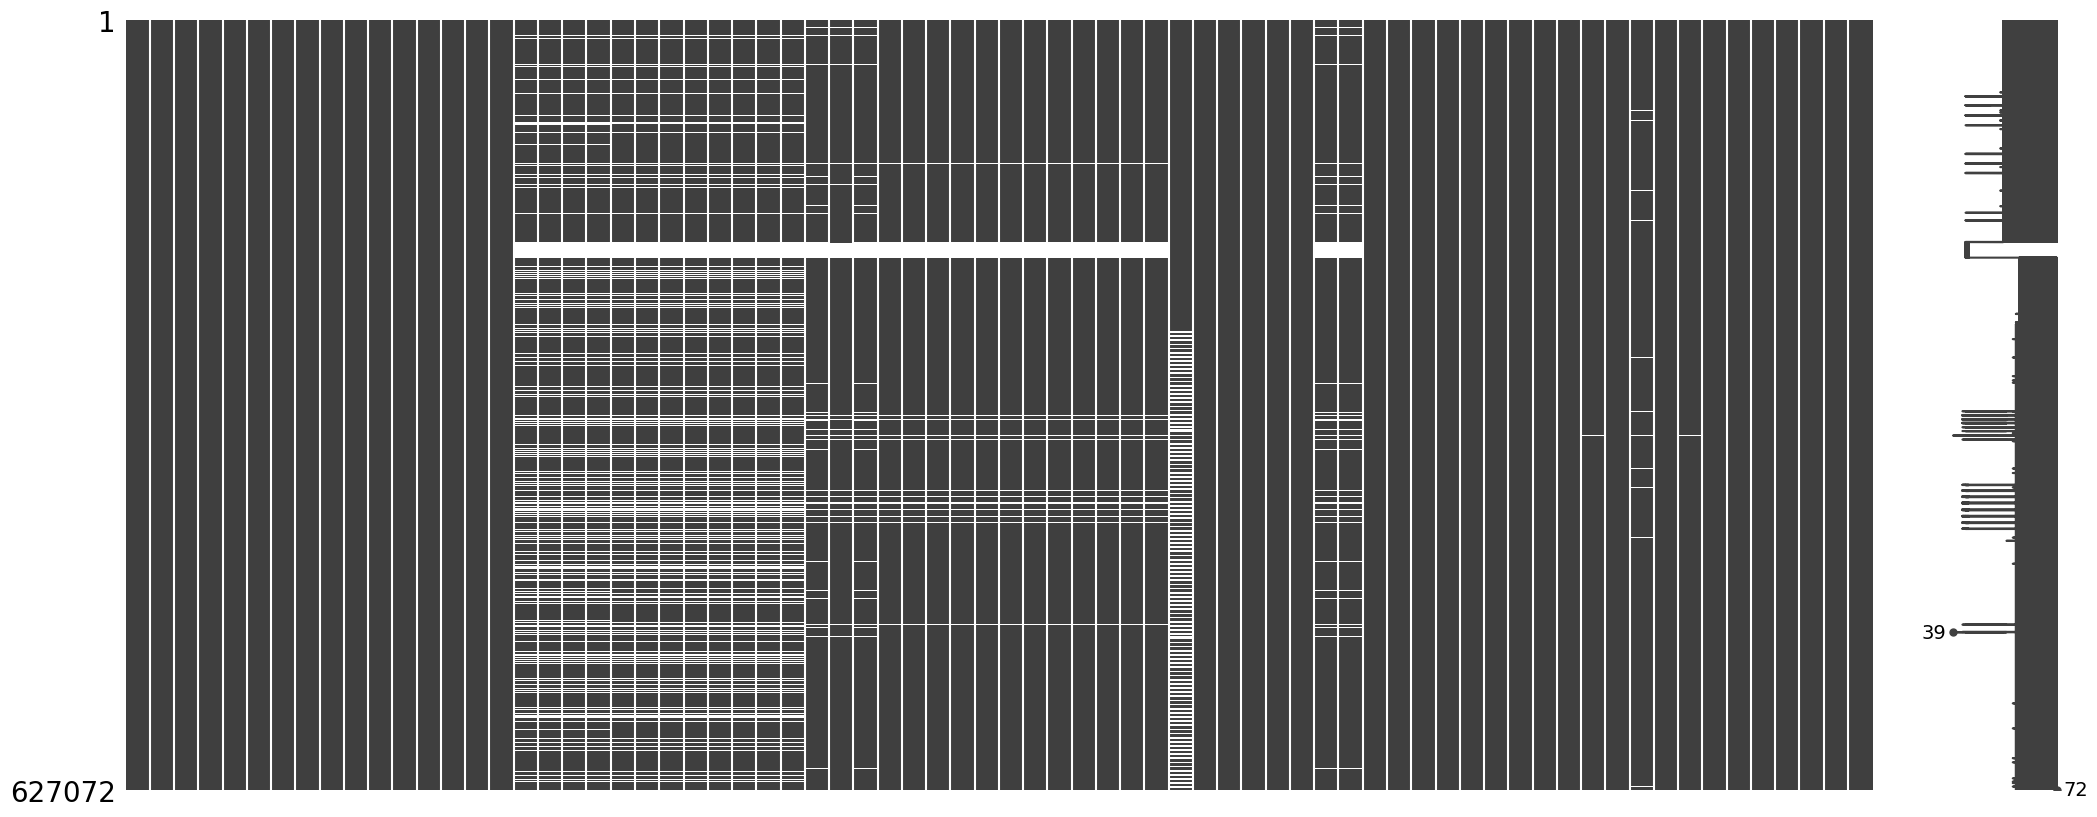

In [76]:
missingno.matrix(merged)

In [77]:
gc.collect()

0

In [78]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'lst_min', 'lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)
imputed_columns = ['lst_min', 'lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

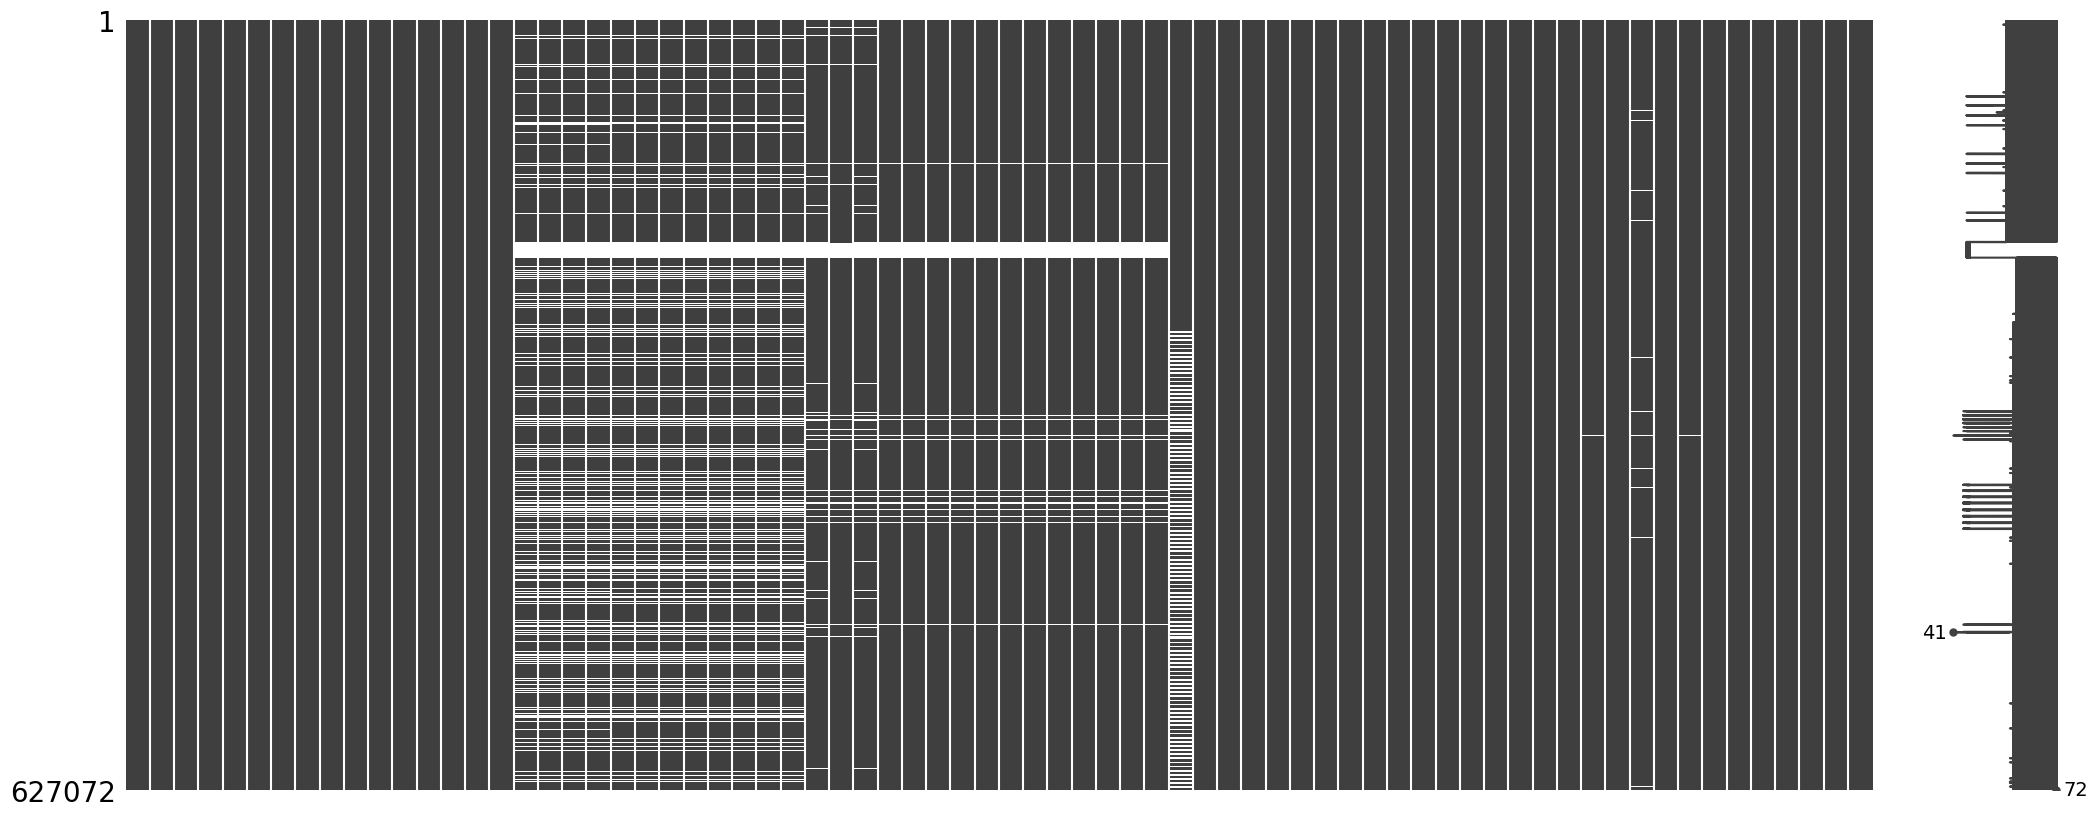

In [79]:
missingno.matrix(merged)

In [80]:
years = merged.year.unique()
years

array([2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023, 2024])

In [81]:
cell_codes_un = merged.cell_number.unique()
cell_codes_un

array([   0,    1,    2, ..., 3263, 3264, 3265], dtype=int64)

In [82]:
rows = []
for year in years:
    for cell in cell_codes_un:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['cell_number'] == cell)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['rainfall_acc'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'cell_number': cell, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [83]:
biovars_df.head(20)

,cell_number,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,0,2009,10.333333,18.500000,45.121951,775.867061,33.000000,-8.000000,41.000000,1.166667,18.833333,18.833333,0.333333,1553.000000,259.000000,65.000000,52.166666,577.000000,289.000000,368.000000,486.000000
1,1,2009,12.500000,24.500000,50.000000,868.907360,41.000000,-8.000000,49.000000,2.333333,22.166667,22.833333,2.333333,1553.000000,259.000000,65.000000,52.166666,577.000000,289.000000,368.000000,486.000000
2,2,2009,11.541667,24.250000,51.595745,791.850059,39.000000,-8.000000,47.000000,2.333333,19.833333,21.000000,1.500000,1553.000000,259.000000,65.000000,52.166666,577.000000,289.000000,368.000000,486.000000
3,3,2009,10.416667,18.666667,44.444444,825.126253,33.000000,-9.000000,42.000000,0.666667,19.666667,19.666667,0.166667,1553.000000,259.000000,65.000000,52.166666,577.000000,289.000000,368.000000,486.000000
4,4,2009,13.166667,24.666667,49.333333,920.062580,41.000000,-9.000000,50.000000,2.166667,23.166667,23.500000,2.166667,1553.000000,259.000000,65.000000,52.166666,577.000000,289.000000,368.000000,486.000000
5,5,2009,11.541667,23.416667,49.822695,803.531505,38.000000,-9.000000,47.000000,2.166667,20.666667,21.000000,1.666667,1553.000000,259.000000,65.000000,52.166666,577.000000,289.000000,368.000000,486.000000
6,6,2009,10.916667,20.500000,45.555556,850.890799,36.000000,-9.000000,45.000000,1.000000,20.833333,20.833333,0.500000,1553.000000,259.000000,65.000000,52.166666,577.000000,289.000000,368.000000,486.000000
7,7,2009,10.666667,18.500000,45.121951,845.128644,33.000000,-8.000000,41.000000,0.833333,20.333333,20.666667,0.333333,1594.000000,266.000000,65.000000,51.633720,585.000000,293.000000,364.000000,520.000000
8,8,2009,12.333333,23.000000,46.938776,897.049034,38.000000,-11.000000,49.000000,1.500000,22.000000,22.333333,1.500000,1594.000000,266.000000,65.000000,51.633720,585.000000,293.000000,364.000000,520.000000
9,9,2009,12.625000,24.583333,49.166667,928.861718,40.000000,-10.000000,50.000000,1.333333,22.666667,23.166667,1.333333,1594.000000,266.000000,65.000000,51.633720,585.000000,293.000000,364.000000,585.000000


In [84]:
merged = pd.merge(merged, biovars_df,  how='left', on=['cell_number', 'year'])

In [85]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2017) & (merged['cell_number'] == 0)]

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
96,0,2017-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2017,1,0.167897,0.204567,-0.030945,-0.204567,0.210751,0.147273,-0.166441,-0.147273,0.059477,0.109452,0.094432,0.109452,-0.841613,-7.948065,-4.394839,-0.841613,3.820714,14.864194,17.458000,-7.948065,-3.616429,3.502258,4.614000,-4.394839,0.102143,9.183226,11.036000,3.287161,5.092673,26.064273,101.901978,101.901978,101.901978,-31.070000,2.430000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,99.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0,10.041667,21.250000,33.730159,1073.113214,32.000000,-31.000000,63.000000,4.500000,16.833333,21.166667,-3.666667,1280.000000,201.000000,30.000000,40.976748,432.000000,201.000000,296.000000,427.000000
97,0,2017-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2017,2,0.175173,0.256335,-0.079900,-0.256335,0.137924,0.319690,-0.101221,-0.319690,0.060888,0.079781,0.069434,0.079781,3.820714,-3.616429,0.102143,-0.841613,3.820714,14.864194,17.458000,-7.948065,-3.616429,3.502258,4.614000,-4.394839,0.102143,9.183226,11.036000,2.608024,4.975027,14.624467,73.024681,174.926659,73.024681,-7.990000,14.910000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,99.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0,10.041667,21.250000,33.730159,1073.113214,32.000000,-31.000000,63.000000,4.500000,16.833333,21.166667,-3.666667,1280.000000,201.000000,30.000000,40.976748,432.000000,201.000000,296.000000,427.000000
98,0,2017-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2017,3,0.281388,0.034969,-0.229791,-0.034969,0.270246,-0.005873,-0.247472,0.005873,0.046997,0.075001,0.069567,0.075001,14.864194,3.502258,9.183226,-0.841613,3.820714,14.864194,17.458000,-7.948065,-3.616429,3.502258,4.614000,-4.394839,0.102143,9.183226,11.036000,3.629853,18.666824,22.515020,68.381906,287.452107,112.525448,-2.190000,21.930000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,99.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0,10.041667,21.250000,33.730159,1073.113214,32.000000,-31.000000,63.000000,4.500000,16.833333,21.166667,-3.666667,1280.000000,201.000000,30.000000,40.976748,432.000000,201.000000,296.000000,427.000000
99,0,2017-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2017,4,0.135842,-0.000944,-0.170619,0.000944,0.176543,-0.022782,-0.205259,0.022782,0.047211,0.024004,0.047695,0.024004,17.458000,4.614000,11.036000,-0.841613,3.820714,14.864194,17.458000,-7.948065,-3.616429,3.502258,4.614000,-4.394839,0.102143,9.183226,11.036000,2.457393,12.524212,16.147306,73.721795,361.173902,73.721795,-2.190000,24.830000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,99.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0,10.041667,21.250000,33.730159,1073.113214,32.000000,-31.000000

In [86]:
df_demographics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [87]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1763,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1764,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1765,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000
1766,EL653,2023,14067.000000,71993.000000,29360.000000,115420.000000,13393.000000,67069.000000,32564.000000,113026.000000


In [88]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [89]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1763,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1764,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1765,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000
1766,EL653,2023,14067.000000,71993.000000,29360.000000,115420.000000,13393.000000,67069.000000,32564.000000,113026.000000


In [90]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

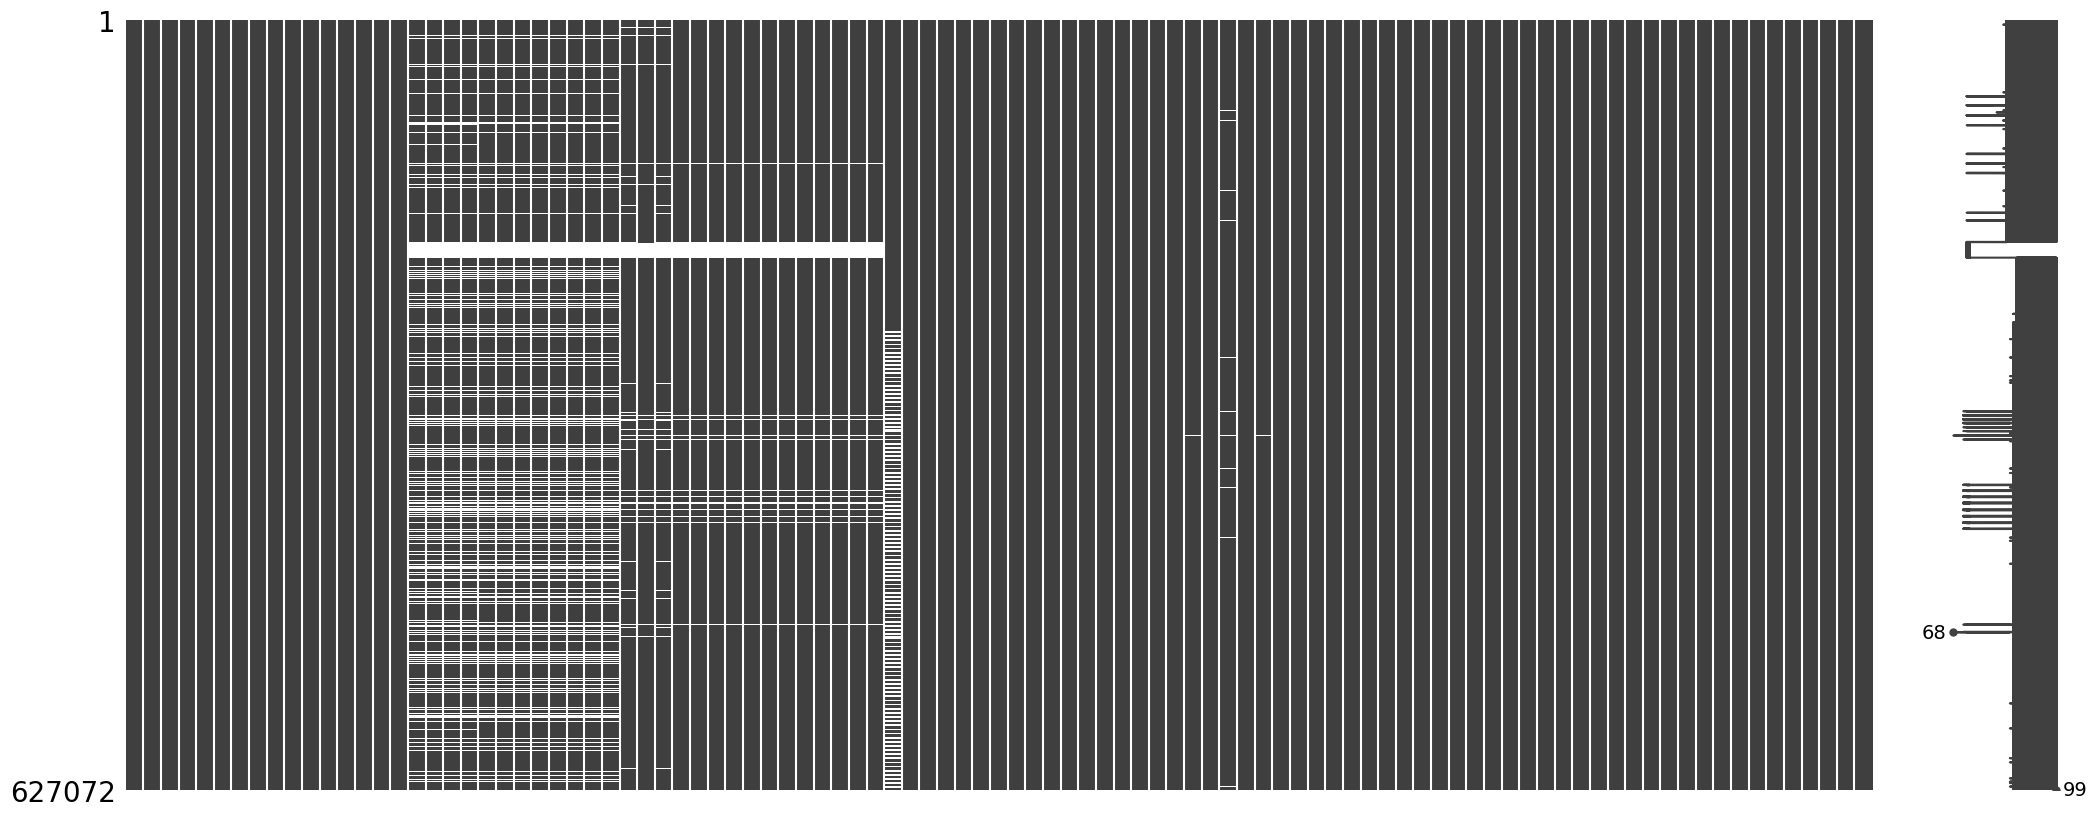

In [91]:
missingno.matrix(dataset)

In [92]:
df_economics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [93]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,9725.080000
1,EL301,2001,10452.130000
2,EL301,2002,11780.170000
3,EL301,2003,12522.310000
4,EL301,2004,13769.510000
...,...,...,...
1191,EL653,2018,3207.990000
1192,EL653,2019,3243.040000
1193,EL653,2020,2907.590000
1194,EL653,2021,3090.650000


In [94]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [95]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,9725.080000
1,EL301,2001,10452.130000
2,EL301,2002,11780.170000
3,EL301,2003,12522.310000
4,EL301,2004,13769.510000
...,...,...,...
1191,EL653,2018,3207.990000
1192,EL653,2019,3243.040000
1193,EL653,2020,2907.590000
1194,EL653,2021,3090.650000


In [96]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

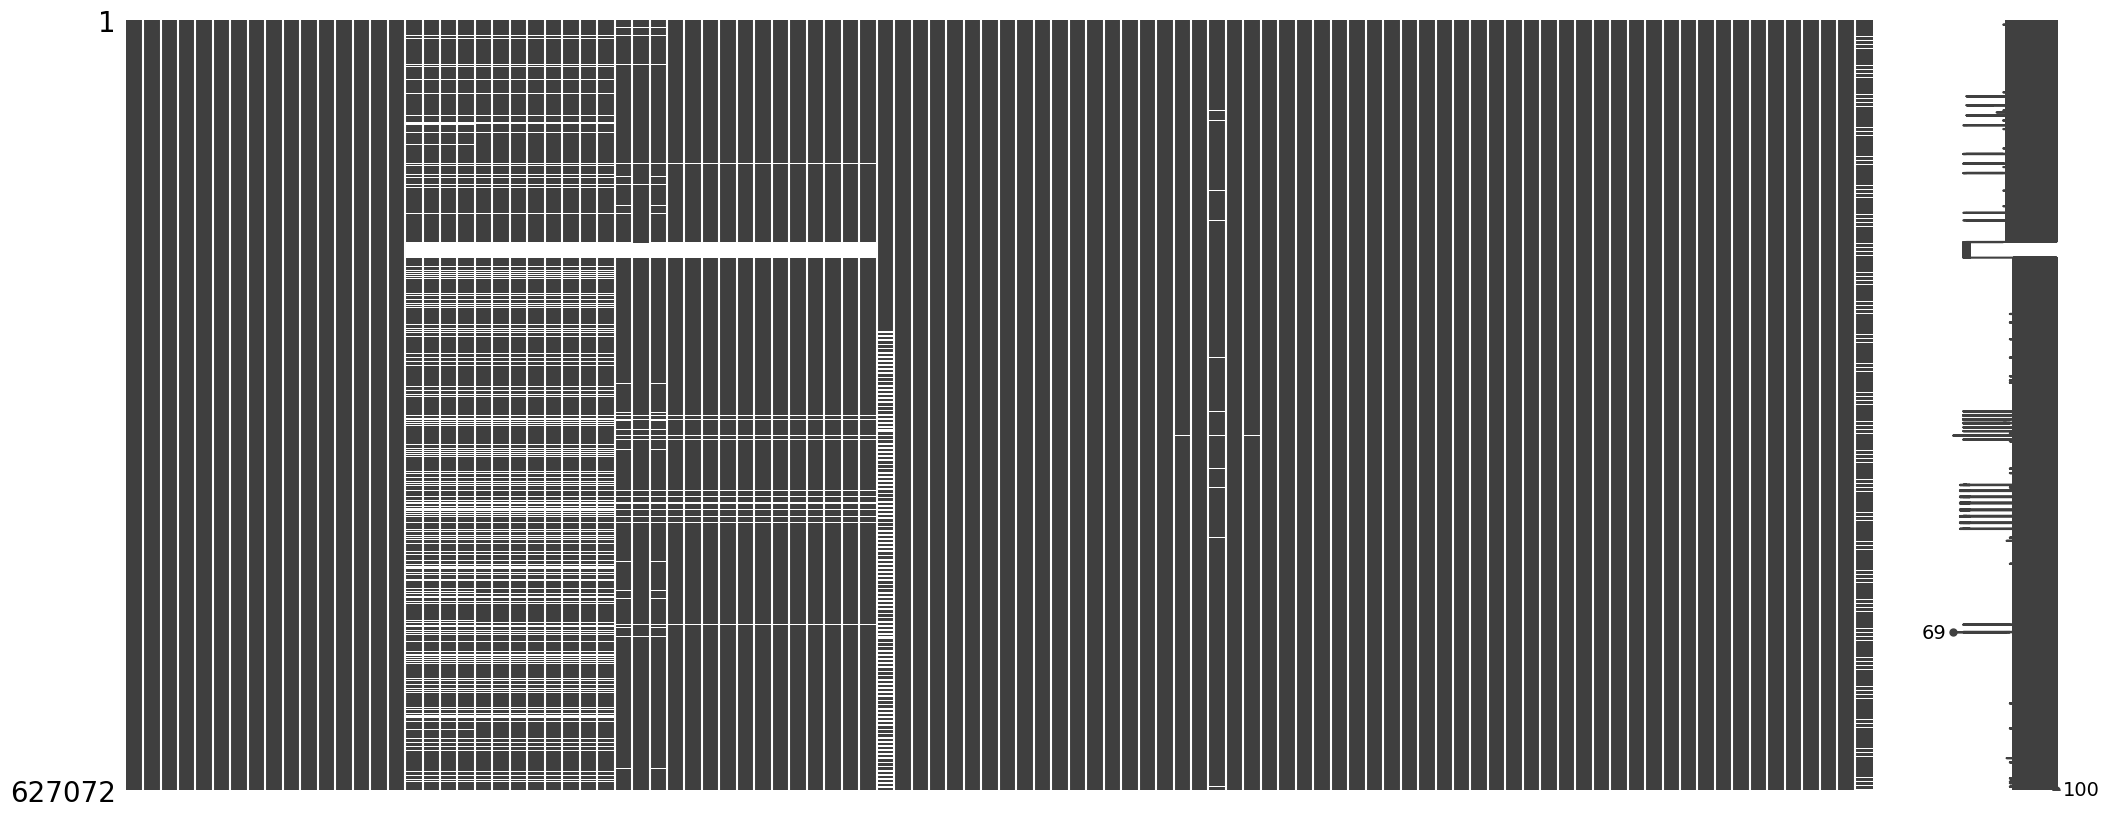

In [97]:
missingno.matrix(dataset)

In [98]:
df_trade = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [99]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
818,EL653,2019,3278.000000,3737.000000
819,EL653,2020,4572.000000,4962.000000
820,EL653,2021,3040.000000,3666.000000
821,EL653,2022,11830.000000,12294.000000


In [100]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [101]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
818,EL653,2019,3278.000000,3737.000000
819,EL653,2020,4572.000000,4962.000000
820,EL653,2021,3040.000000,3666.000000
821,EL653,2022,11830.000000,12294.000000


In [102]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

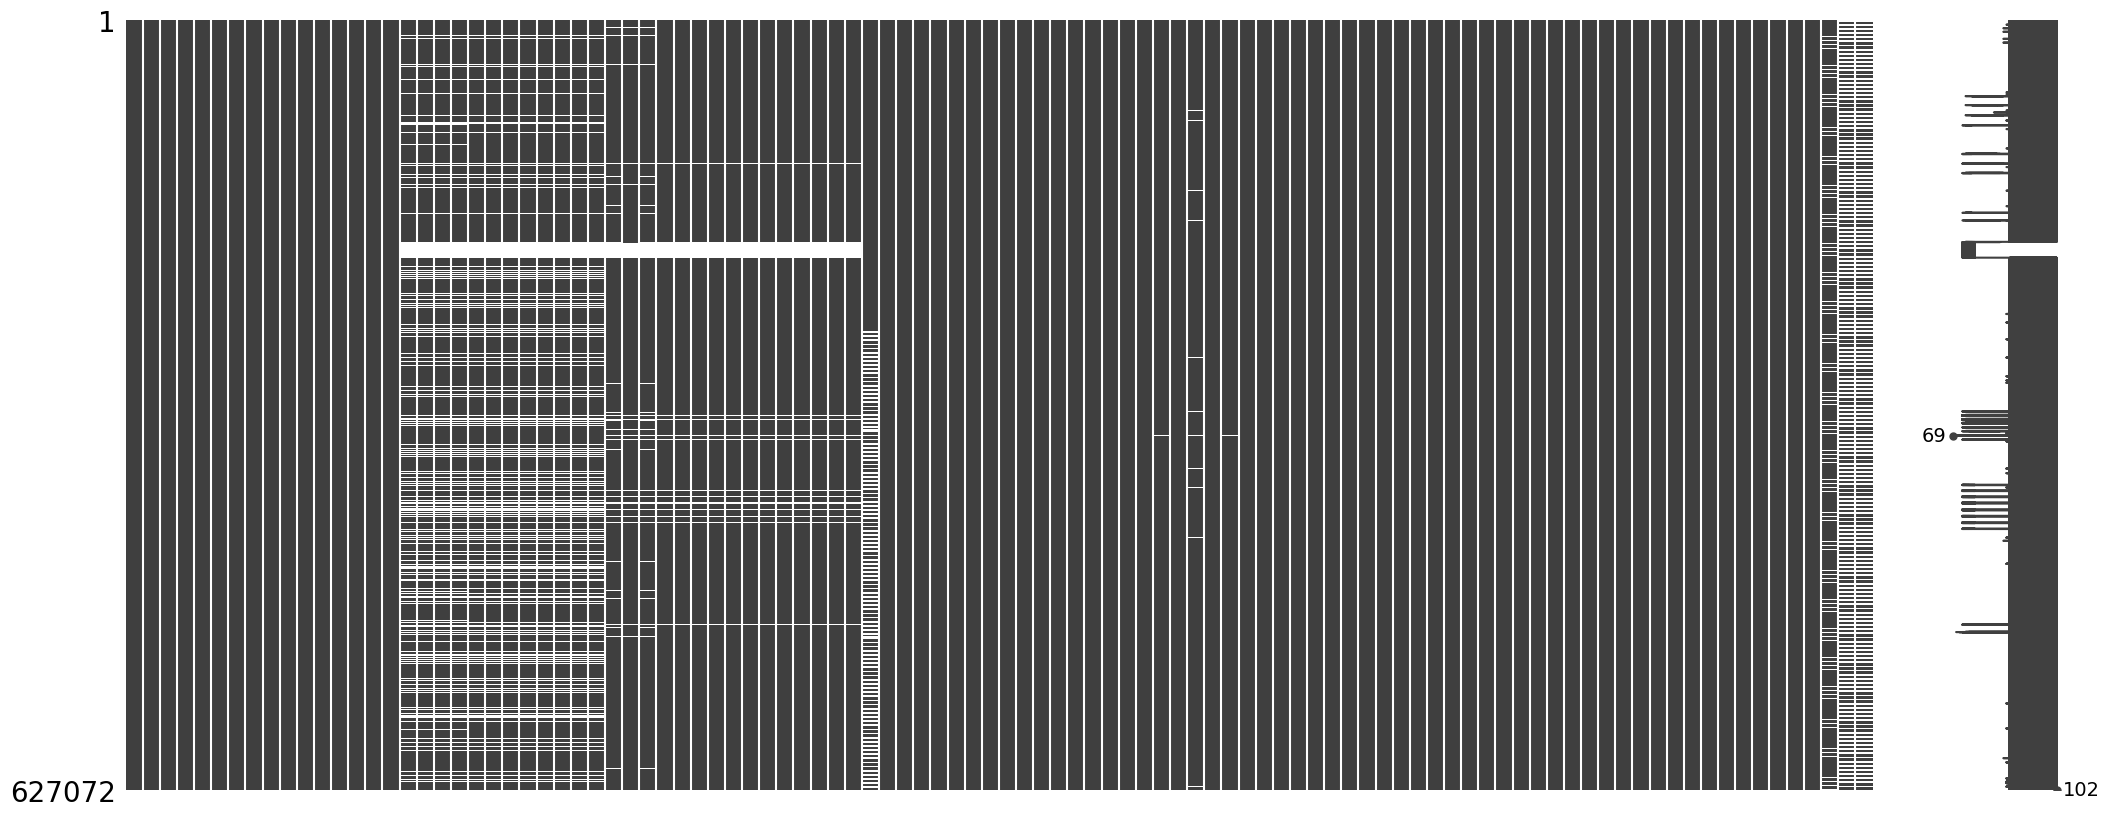

In [103]:
missingno.matrix(dataset)

In [104]:
missing = describe_dataframe(dataset, remove_zeros=True)

In [105]:
missing

,Column,Missing
16,ndvi,19.372600
17,ndmi,19.372600
18,ndwi,19.372600
19,ndbi,19.372600
20,ndvi_mean,18.689600
21,ndmi_mean,18.689600
22,ndwi_mean,18.689600
23,ndbi_mean,18.689600
24,ndvi_std,18.689600
25,ndmi_std,18.689600


In [106]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2009-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2009,1,0.048867,0.645236,0.695046,-0.645236,0.103399,0.631934,0.587367,-0.631934,0.048829,0.089425,0.114558,0.089425,2.065484,-2.724545,0.066364,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,8.378167,118.773868,198.685847,259.152060,259.723176,259.723176,-7.790000,8.770000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,98.000000,10,98.000000,4,4,6,4,4,2,0,10.333333,18.500000,45.121951,775.867061,33.000000,-8.000000,41.000000,1.166667,18.833333,18.833333,0.333333,1553.000000,259.000000,65.000000,52.166666,577.000000,289.000000,368.000000,486.000000,7608.000000,29799.000000,10403.000000,47810.000000,6962.000000,29625.000000,13770.000000,50357.000000,1284.430000,NaN,NaN
1,0,2009-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2009,2,0.048867,0.645236,0.695046,-0.645236,0.103399,0.631934,0.587367,-0.631934,0.048829,0.089425,0.114558,0.089425,1.051429,-3.054286,-1.001429,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,2.519676,1.651490,12.768820,71.318846,330.274096,70.550920,-8.910000,8.370000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,98.000000,10,98.000000,4,4,6,4,4,2,0,10.333333,18.500000,45.121951,775.867061,33.000000,-8.000000,41.000000,1.166667,18.833333,18.833333,0.333333,1553.000000,259.000000,65.000000,52.166666,577.000000,289.000000,368.000000,486.000000,7608.000000,29799.000000,10403.000000,47810.000000,6962.000000,29625.000000,13770.000000,50357.000000,1284.430000,NaN,NaN
2,0,2009-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2009,3,0.211360,0.362865,0.190696,-0.362865,0.188228,0.411424,0.260076,-0.411424,0.029014,0.043821,0.062553,0.043821,4.324839,-4.054516,0.135161,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,5.078133,45.941999,78.429424,147.547585,487.696225,157.422129,-7.770000,8.630000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,98.000000,10,98.000000,4,4,6,4,4,2,0,10.333333,18.500000,45.121951,775.867061,33.000000,-8.000000,41.000000,1.166667,18.833333,18.833333,0.333333,1553.000000,259.000000,65.000000,52.166666,577.000000,289.000000,368.000000,486.000000,7608.000000,29799.000000,10403.000000,47810.000000,6962.000000,29625.000000,13770.000000,50357.000000,1284.430000,NaN,NaN
3,0,2009-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2009,4,0.306158,0.203394,-0.063552,-0.203394,0.287738,0.176433,-0.085433,-0.176433,0.026739,0

In [107]:
dataset.reset_index(inplace=True, drop=True)

In [108]:
# dataset['cases'].value_counts()

In [109]:
# dataset['cases'].sum()

In [110]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2009-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2009,1,0.048867,0.645236,0.695046,-0.645236,0.103399,0.631934,0.587367,-0.631934,0.048829,0.089425,0.114558,0.089425,2.065484,-2.724545,0.066364,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,8.378167,118.773868,198.685847,259.152060,259.723176,259.723176,-7.790000,8.770000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,98.000000,10,98.000000,4,4,6,4,4,2,0,10.333333,18.500000,45.121951,775.867061,33.000000,-8.000000,41.000000,1.166667,18.833333,18.833333,0.333333,1553.000000,259.000000,65.000000,52.166666,577.000000,289.000000,368.000000,486.000000,7608.000000,29799.000000,10403.000000,47810.000000,6962.000000,29625.000000,13770.000000,50357.000000,1284.430000,NaN,NaN
1,0,2009-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2009,2,0.048867,0.645236,0.695046,-0.645236,0.103399,0.631934,0.587367,-0.631934,0.048829,0.089425,0.114558,0.089425,1.051429,-3.054286,-1.001429,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,2.519676,1.651490,12.768820,71.318846,330.274096,70.550920,-8.910000,8.370000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,98.000000,10,98.000000,4,4,6,4,4,2,0,10.333333,18.500000,45.121951,775.867061,33.000000,-8.000000,41.000000,1.166667,18.833333,18.833333,0.333333,1553.000000,259.000000,65.000000,52.166666,577.000000,289.000000,368.000000,486.000000,7608.000000,29799.000000,10403.000000,47810.000000,6962.000000,29625.000000,13770.000000,50357.000000,1284.430000,NaN,NaN
2,0,2009-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2009,3,0.211360,0.362865,0.190696,-0.362865,0.188228,0.411424,0.260076,-0.411424,0.029014,0.043821,0.062553,0.043821,4.324839,-4.054516,0.135161,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105000,5.078133,45.941999,78.429424,147.547585,487.696225,157.422129,-7.770000,8.630000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,98.000000,10,98.000000,4,4,6,4,4,2,0,10.333333,18.500000,45.121951,775.867061,33.000000,-8.000000,41.000000,1.166667,18.833333,18.833333,0.333333,1553.000000,259.000000,65.000000,52.166666,577.000000,289.000000,368.000000,486.000000,7608.000000,29799.000000,10403.000000,47810.000000,6962.000000,29625.000000,13770.000000,50357.000000,1284.430000,NaN,NaN
3,0,2009-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2009,4,0.306158,0.203394,-0.063552,-0.203394,0.287738,0.176433,-0.085433,-0.176433,0.026739,0

In [111]:
cols = dataset.columns

In [112]:
print(cols)


Index(['cell_number', 'dt_placement', 'NUTS1_ID', 'NUTS1_NAME', 'NUTS2_ID',
       'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME', 'x',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=102)


In [113]:
len(cols)

102

In [114]:
years = dataset.year.unique().tolist()

In [115]:
for item in years:
    dataset[dataset.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{item}.csv", encoding = enc, index = False)